**Phase–Locking of Local Oscillations**

*Group Members: Christopher Hayashi Bruce, Rezwana Hussainzada*

---
### Steps 1 & 2:


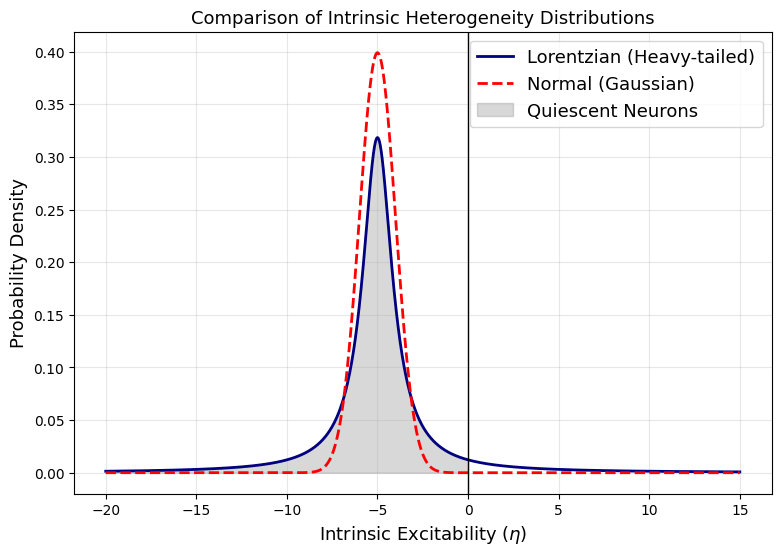

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy


mu_bar = -5
delta = 1.0

eta = np.linspace(-20, 15, 2000)


lorentzian = cauchy.pdf(eta, loc=mu_bar, scale=delta)
normal = norm.pdf(eta, loc=mu_bar, scale=delta)

plt.figure(figsize=(9, 6))
plt.plot(eta, lorentzian, label='Lorentzian (Heavy-tailed)', color='navy', linewidth=2)
plt.plot(eta, normal, label='Normal (Gaussian)', color='red', linestyle='--', linewidth=2)

eta_neg = np.linspace(-20, 0, 500)
plt.fill_between(eta_neg, cauchy.pdf(eta_neg, loc=mu_bar, scale=delta), color='gray', alpha=0.3, label='Quiescent Neurons')

plt.axvline(0, color='black', linewidth=1)
plt.xlabel(r'Intrinsic Excitability ($\eta$)', fontsize=13)
plt.ylabel('Probability Density', fontsize=13)
plt.title('Comparison of Intrinsic Heterogeneity Distributions', fontsize=13)
plt.legend(fontsize=13, frameon=True)
plt.grid(True, alpha=0.3)
plt.show()

This distribution illustrates that with a mean excitability of $\bar{\eta} = -5$, the majority of neurons are not intrinsically oscillatory. Consequently, the emergence of a global oscillation in the network is driven primarily by synaptic currents rather than individual neural dynamics.

In [2]:
!pip install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.7 MB/s eta 0:00:00


In [7]:
from brian2 import *
import matplotlib.pyplot as plt
import numpy as np
# Set Brian2 preferences
prefs.codegen.target = 'numpy'

Running simulation...
Simulation complete!


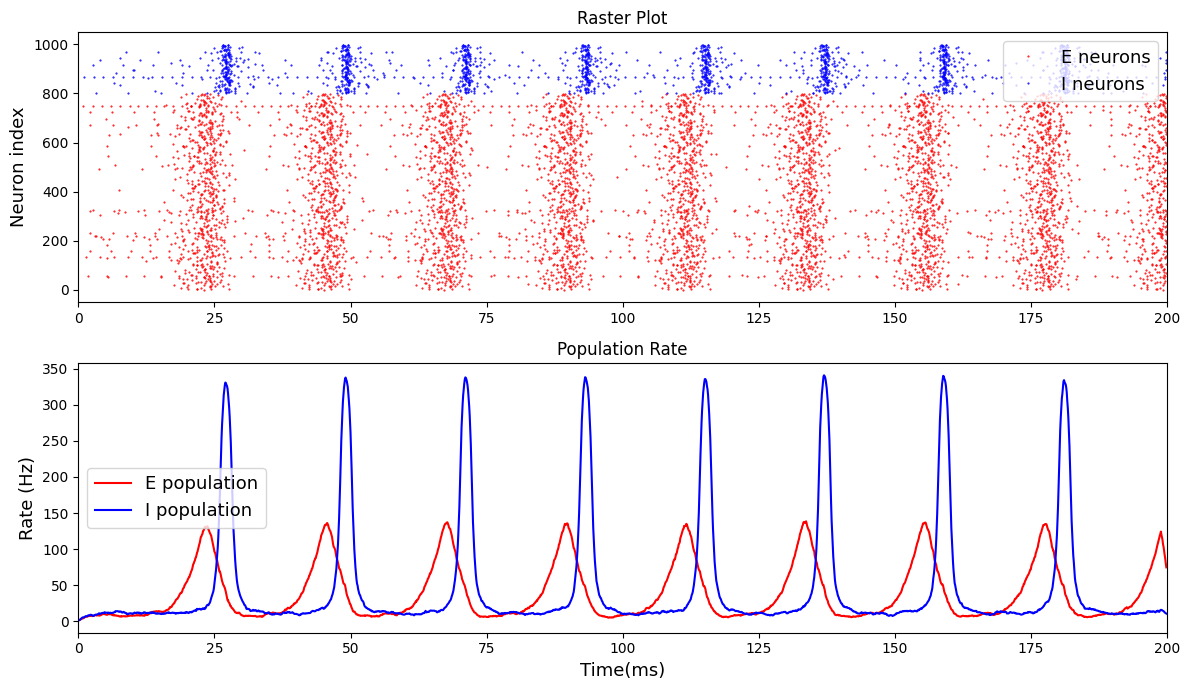


Network Statistics:
Total E spikes: 15879
Total I spikes: 18535
Mean E rate: 39.70 Hz
Mean I rate: 46.34 Hz


In [66]:
"""
Implementation of Quadratic Integrate-and-Fire (QIF) network
from Dumont and Gutkin (2019) using Brian2
"""

start_scope()

# ============================================================
# PARAMETERS (from Figure 2 caption - PING oscillation)
# ============================================================

# Network size
Ne = Ni = 2000

# Time constants
tau_e = 10 * ms
tau_i = 10 * ms
tau_s = 1 * ms
tau_e_dim = tau_i_dim = 10

# Lorentzian distribution parameters
eta_mean_e = eta_mean_i = -5.0
Delta_e = Delta_i = 1

# Synaptic weights
Jee = 0.0
Jei = 15.0
Jie = 15.0
Jii = 0.0

# External input
Iext_e = 10
Iext_i = 0

# Threshold and reset
v_th = 50.0
v_r = -50.0
input_time = 10*ms

# Simulation duration
duration = 200 * ms

# ============================================================
# NEURON MODEL EQUATIONS
# ============================================================

# QIF equation for excitatory neurons
eqs_e = '''
dv/dt = (eta_e + v**2 + I_total) / tau_e : 1
I_total = Iext_e * int(t>input_time) + tau_e_dim*(s_ee - s_ei) : 1
ds_ee/dt = -s_ee / tau_s : 1
ds_ei/dt = -s_ei / tau_s : 1
eta_e : 1
'''

# QIF equation for inhibitory neurons
eqs_i = '''
dv/dt = (eta_i + v**2 + I_total) / tau_i : 1
I_total = Iext_i * int(t>input_time) + tau_i_dim*(s_ie - s_ii) : 1
ds_ie/dt = -s_ie / tau_s : 1
ds_ii/dt = -s_ii / tau_s : 1
eta_i : 1
'''

# CREATE NEURON GROUPS

E_neurons = NeuronGroup(Ne, eqs_e, threshold='v > v_th', reset='v = v_r',
                        method='euler')
I_neurons = NeuronGroup(Ni, eqs_i, threshold='v > v_th', reset='v = v_r',
                        method='euler')

# init heterogenous params

np.random.seed(42)
E_neurons.eta_e = np.random.standard_cauchy(Ne) * Delta_e + eta_mean_e
I_neurons.eta_i = np.random.standard_cauchy(Ni) * Delta_i + eta_mean_i

# Initialize membrane potentials
E_neurons.v = np.random.uniform(-1, 1, Ne)
I_neurons.v = np.random.uniform(-1, 1, Ni)

# Initialize synaptic variables
E_neurons.s_ee = 0
E_neurons.s_ei = 0
I_neurons.s_ie = 0
I_neurons.s_ii = 0
#____
# CREATE SYNAPSES
#____
# E -> E synapses
if Jee != 0:
    syn_ee = Synapses(E_neurons, E_neurons, on_pre='s_ee_post += Jee / Ne')
    syn_ee.connect()

# I -> E synapses (inhibition of excitatory population)
syn_ie = Synapses(I_neurons, E_neurons, on_pre='s_ei_post += Jei / Ni')
syn_ie.connect()

# E -> I synapses (excitation of inhibitory population)
syn_ei = Synapses(E_neurons, I_neurons, on_pre='s_ie_post += Jie / Ne')
syn_ei.connect()

# I -> I synapses
if Jii != 0:
    syn_ii = Synapses(I_neurons, I_neurons, on_pre='s_ii_post += Jii / Ni')
    syn_ii.connect()

# MONITORS

spike_mon_e = SpikeMonitor(E_neurons)
spike_mon_i = SpikeMonitor(I_neurons)
rate_mon_e = PopulationRateMonitor(E_neurons)
rate_mon_i = PopulationRateMonitor(I_neurons)

q = 10
state_mon_e = StateMonitor(E_neurons, ['v', 'I_total', 's_ee', 's_ei'],
                           record=range(q))
state_mon_i = StateMonitor(I_neurons, ['v', 'I_total', 's_ie', 's_ii'],
                           record=range(q))

# RUN SIM

print("Running simulation...")
run(duration)
print("Simulation complete!")

# PLOTS

fig, axes = plt.subplots(2, 1, figsize=(12,7))

# Plot 1: Raster plot
ax1 = axes[0]
n_e_sample = 800
n_i_sample = 200

e_mask = spike_mon_e.i < n_e_sample
i_mask = spike_mon_i.i < n_i_sample

ax1.plot(spike_mon_e.t[e_mask]/ms, spike_mon_e.i[e_mask], '.r',
         markersize=1, label='E neurons')
ax1.plot(spike_mon_i.t[i_mask]/ms, spike_mon_i.i[i_mask] + n_e_sample, '.b',
         markersize=1, label='I neurons')
ax1.set_ylabel('Neuron index', fontsize=13)
ax1.set_title('Raster Plot')
ax1.legend(loc='upper right', fontsize=13, frameon=True)
ax1.set_xlim(0, duration/ms)


# Plot 2 & 3: Population firing rates
ax2 = axes[1]
ax2.plot(rate_mon_e.t/ms, rate_mon_e.smooth_rate(window='flat', width=2*ms)/Hz,
         'r', label='E population')
ax2.plot(rate_mon_i.t/ms, rate_mon_i.smooth_rate(window='flat', width=2*ms)/Hz,
         'b', label='I population')
ax2.set_xlabel('Time(ms)', fontsize=13)
ax2.set_ylabel('Rate (Hz)', fontsize=13)
ax2.set_title('Population Rate')
ax2.legend(fontsize=13, frameon=True)
ax2.set_xlim(0, duration/ms)

plt.tight_layout()
plt.savefig('qif_network_ping.png', dpi=150)
plt.show()

print("\nNetwork Statistics:")
print(f"Total E spikes: {len(spike_mon_e.t)}")
print(f"Total I spikes: {len(spike_mon_i.t)}")
if duration > 0*second:
    print(f"Mean E rate: {len(spike_mon_e.t) / (Ne * duration/second):.2f} Hz")
    print(f"Mean I rate: {len(spike_mon_i.t) / (Ni * duration/second):.2f} Hz")

The network is constituted of one excitatory (E) and one inhibitory (I) population. In this configuration, a constant external input ($I^{ext}_e = 10$) is provided to the E-cells, while the I-cells receive no direct external drive ($I^{ext}_i = 0$). This input causes the E-cells to fire first; their spikes then provide a recruitment signal that excites the I-cells. Once the I-cells spike, they provide feedback inhibition that briefly silences the E-population. As this inhibition decays, the E-cells reach their firing threshold again, restarting the cycle. This rhythmic interplay between excitation and delayed inhibition generates the PING oscillation observed in our results.

---




### Step 3 :
Now we want to explore the effects of varying relevant
parameters, like the external input to E-cells and I-cells.

In this section we defined four functions to visulaise the change of oscillation coherence and firing rate of popultaions:

1. *1st Function*, "compute_power_spectrum" calculates the Power Spectrum of the network activity. It returns 'freqs' (Hz) and 'power' (Hz^2) to identify dominant oscillation speeds.

2. *2nd function*, "compute_coherence" Returns the oscillation coherence and the peak frequency. The oscillation coherence is quantified as the ratio of the peak power(in Gamma band) to the mean power of the spectrum $\sqrt{\frac{peak\ power}{mean\ power}}$. This indicates that how much of the total firing energy is concentrated into highest frequency in Gamma band versus how much is wasted as stochastic, asynchronous noise. Coherence quantifies the strength of the rhythm, particularly as we vary parameters like external input, ensuring that a high coherence value truly reflects a concentrated temporal alignment of spikes across the population.

3. *3th function*, "run_ping_network" simulates a spiking neural network consisting of Excitatory (E) and Inhibitory (I) populations based on the Quadratic Integrate-and-Fire (QIF) model. It utilizes PopulationRateMonitor to record the collective firing rate of each group.

4. *4th function*, "parameter_sweep" automates the process of investigating how the network's dynamics change under different conditions. It iterates through a defined range of values for external input while keeping others constant. Fixed values for external input currents to exticatory and inibitory populations are 10 and 3, respectively. It returns the coherence of both populations' oscillation and their average firing rate.


In [58]:
from scipy.fft import fft, fftfreq
from scipy import signal
from scipy.signal import find_peaks

In [59]:
# 1st function:
def compute_power_spectrum(rate_monitor, time_window=(50, 150)): #time_window should be the time of external input to duration/ms; (50,150) should be adequate if not specified
    t = rate_monitor.t/ms
    rate = rate_monitor.smooth_rate(window='flat', width=2*ms)/Hz
    mask = (t >= time_window[0]) & (t <= time_window[1])
    t_analysis = t[mask]
    rate_analysis = rate[mask]
    rate_analysis = rate_analysis # - np.mean(rate_analysis) #don't subtract mean b/c this messes up the coherence measure
    dt = np.mean(np.diff(t_analysis))
    N = len(rate_analysis)
    freqs = fftfreq(N, dt)[:N//2] #[] masks for only positives
    power = (np.abs(fft(rate_analysis)[:N//2])**2) / N
    #power = power/max(power) #normalize
    return freqs, power


In [60]:
# 2nd function:
def compute_coherence(freqs, power, gamma_range=(0.03, 0.15)): #these values were chosen by looking at the unnormalized power spectrum. also aligns with the 30hz to 150hz in paper
    """
    Compute oscillation coherence: sqrt(peak_power / mean_power)
    Measures synchrony of population activity
    """
    # mean firing rate component
    mean_idx = np.argmin(np.abs(freqs))
    mean_power = power[mean_idx]

    # Find peak in gamma range
    gamma_mask = (freqs >= gamma_range[0]) & (freqs <= gamma_range[1])

    if np.any(gamma_mask) and mean_power > 1e-10:
        gamma_power = power[gamma_mask]
        gamma_freqs = freqs[gamma_mask]

        peak_idx = np.argmax(gamma_power)
        peak_power = gamma_power[peak_idx]
        peak_freq = gamma_freqs[peak_idx]

        coherence = np.sqrt(peak_power / mean_power)
    else:
        coherence = 0.0
        peak_freq = 0.0

    return coherence, peak_freq


In [61]:
# 3th function:
def run_ping_network(Iext_e, Iext_i, duration=800*ms, Ne=2000, Ni=2000):
    """Run PING network with given external inputs"""
    start_scope()

    # Time constants
    tau_e = 10 * ms
    tau_i = 10 * ms
    tau_s = 1 * ms
    tau_e_dim = tau_i_dim = 10

    # Lorentzian distribution parameters
    eta_mean_e = eta_mean_i = -5.0
    Delta_e = Delta_i = 1.0

    # Synaptic weights
    Jee = 0.0
    Jei = 15.0
    Jie = 15.0
    Jii = 0.0

    # Threshold and reset
    v_th = 50.0
    v_r = -50.0
    input_time = 10*ms

    # QIF equations
    eqs_e = '''
    dv/dt = (eta_e + v**2 + I_total) / tau_e : 1
    I_total = Iext_e * int(t>input_time) + tau_e_dim*(s_ee - s_ei) : 1
    ds_ee/dt = -s_ee / tau_s : 1
    ds_ei/dt = -s_ei / tau_s : 1
    eta_e : 1
    Iext_e : 1
    '''

    eqs_i = '''
    dv/dt = (eta_i + v**2 + I_total) / tau_i : 1
    I_total = Iext_i * int(t>input_time) + tau_i_dim*(s_ie - s_ii) : 1
    ds_ie/dt = -s_ie / tau_s : 1
    ds_ii/dt = -s_ii / tau_s : 1
    eta_i : 1
    Iext_i : 1
    '''

    # Create neuron groups
    E_neurons = NeuronGroup(Ne, eqs_e, threshold='v > v_th', reset='v = v_r', method='euler')
    I_neurons = NeuronGroup(Ni, eqs_i, threshold='v > v_th', reset='v = v_r', method='euler')

    # Initialize
    np.random.seed(42)
    E_neurons.eta_e = np.random.standard_cauchy(Ne) * Delta_e + eta_mean_e
    I_neurons.eta_i = np.random.standard_cauchy(Ni) * Delta_i + eta_mean_i
    E_neurons.v = np.random.uniform(-1, 1, Ne)
    I_neurons.v = np.random.uniform(-1, 1, Ni)
    E_neurons.Iext_e = Iext_e
    I_neurons.Iext_i = Iext_i

    # Synapses
    syn_ie = Synapses(I_neurons, E_neurons, on_pre='s_ei_post += Jei / Ni')
    syn_ie.connect()
    syn_ei = Synapses(E_neurons, I_neurons, on_pre='s_ie_post += Jie / Ne')
    syn_ei.connect()

    # Monitors
    rate_mon_e = PopulationRateMonitor(E_neurons)
    rate_mon_i = PopulationRateMonitor(I_neurons)

    # Run
    run(duration)


    start_step = int(50*ms / defaultclock.dt)
    avg_firing_e = np.mean(rate_mon_e.rate[start_step:])
    avg_firing_i = np.mean(rate_mon_i.rate[start_step:])


    return rate_mon_e, rate_mon_i, avg_firing_e, avg_firing_i



In [62]:
# Parameter sweep
# 4th function:
def parameter_sweep(param_name='Iext_e', param_range=np.linspace(0, 20, 21)):
    """
    Sweep one parameter while keeping the other fixed
    param_name: 'Iext_e' or 'Iext_i'
    """
    coherence_e = []
    coherence_i = []
    peak_freq_e = []
    peak_freq_i = []
    avg_rates_e = []
    avg_rates_i = []


    # Fixed values
    fixed_Iext_e = 10.0
    fixed_Iext_i = 3.0

    print(f"\nRunning parameter sweep: {param_name}")
    print(f"Range: {param_range[0]:.1f} to {param_range[-1]:.1f}")
    print("-" * 60)

    for idx, param_value in enumerate(param_range):
        # Set parameters
        if param_name == 'Iext_e':
            Iext_e = param_value
            Iext_i = fixed_Iext_i
        else:  # 'Iext_i'
            Iext_e = fixed_Iext_e
            Iext_i = param_value

        #print(f"[{idx+1}/{len(param_range)}] Iext_e={Iext_e:.1f}, Iext_i={Iext_i:.1f}...", end=' ')

        # Run simulation
        rate_mon_e, rate_mon_i, rate_e, rate_i = run_ping_network(Iext_e, Iext_i)

        avg_rates_e.append(rate_e)
        avg_rates_i.append(rate_i)

        # Analyze E population
        freqs_e, power_e = compute_power_spectrum(rate_mon_e)
        coh_e, freq_e = compute_coherence(freqs_e, power_e)
        #coherence_e.append(coh_e)
        #peak_freq_e.append(freq_e)

        # Analyze I population
        freqs_i, power_i = compute_power_spectrum(rate_mon_i)
        coh_i, freq_i = compute_coherence(freqs_i, power_i)
        #coherence_i.append(coh_i)
        #peak_freq_i.append(freq_i)

        threshold = 0.1
        peak_freq_e.append(freq_e if coh_e > threshold else np.nan)
        peak_freq_i.append(freq_i if coh_i > threshold else np.nan)

        coherence_e.append(coh_e)
        coherence_i.append(coh_i)

        if idx % 5 == 0 or idx == len(param_range) - 1:
            print(f"[{idx+1}/{len(param_range)}] {param_name}={param_value:.1f} | "
                  f"E_Coh={coh_e:.2f}, I_Coh={coh_i:.2f}")


        print(f"E coherence={coh_e:.3f}, I coherence={coh_i:.3f}")
    print("-" * 60 + "\nSweep Completed.")
    return coherence_e, coherence_i, avg_rates_e, avg_rates_i



### Visualization


In [63]:
#5th function
def plot_network_analysis(param_range, coherence_e, coherence_i, avg_rates_e, avg_rates_i, param_name):

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    ax1.plot(param_range, coherence_e, 'ro-', label='E population', linewidth=2, markersize=6, alpha=0.7)
    ax1.plot(param_range, coherence_i, 'bs-', label='I population', linewidth=2, markersize=6, alpha=0.7)
    ax1.set_ylabel('Oscillation Coherence', fontsize=12)
    ax1.set_title(f'Network Dynamics Analysis vs {param_name}', fontsize=14)
    ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect Coherence')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)


    ax2.plot(param_range, avg_rates_e, 'ro-', label='E Population', linewidth=2, markersize=6, alpha=0.7)
    ax2.plot(param_range, avg_rates_i, 'bo-', label='I Population', linewidth=2, markersize=6, alpha=0.7)
    ax2.set_xlabel(param_name, fontsize=13)
    ax2.set_ylabel('Average Firing Rate (Hz)', fontsize=13)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig


Running parameter sweep: Iext_e
Range: 0.0 to 20.0
------------------------------------------------------------


WARNING    The object 'synapses_3' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipython-input-3319225351.py', line 96, in <cell line: 0>
    syn_ie = Synapses(I_neurons, E_neurons, on_pre='s_ei_post += Jei / Ni') [brian2.core.base.unused_brian_object]
WARNING    The object 'neurongroup_10' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipython-input-3319225351.py', line 67, in <cell line: 0>
    E_neurons = NeuronGroup(Ne, eqs_e, threshold='v > v_th', reset='v = v_r', [brian2.core.base.unused_brian_object]
WARNING    The object 'neurongroup_12' is getting delete

[1/21] Iext_e=0.0 | E_Coh=0.02, I_Coh=0.02
E coherence=0.017, I coherence=0.018


WARNING    'Iext_e' is an internal variable of group 'neurongroup_4', but also exists in the run namespace with the value np.float64(1.0). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


E coherence=0.019, I coherence=0.024


...

E coherence=0.788, I coherence=0.810


WARNING    'Iext_e' is an internal variable of group 'neurongroup_4', but also exists in the run namespace with the value np.float64(19.0). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


E coherence=0.634, I coherence=0.648


WARNING    'Iext_e' is an internal variable of group 'neurongroup_6', but also exists in the run namespace with the value np.float64(20.0). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[21/21] Iext_e=20.0 | E_Coh=0.63, I_Coh=0.63
E coherence=0.628, I coherence=0.632
------------------------------------------------------------
Sweep Completed.


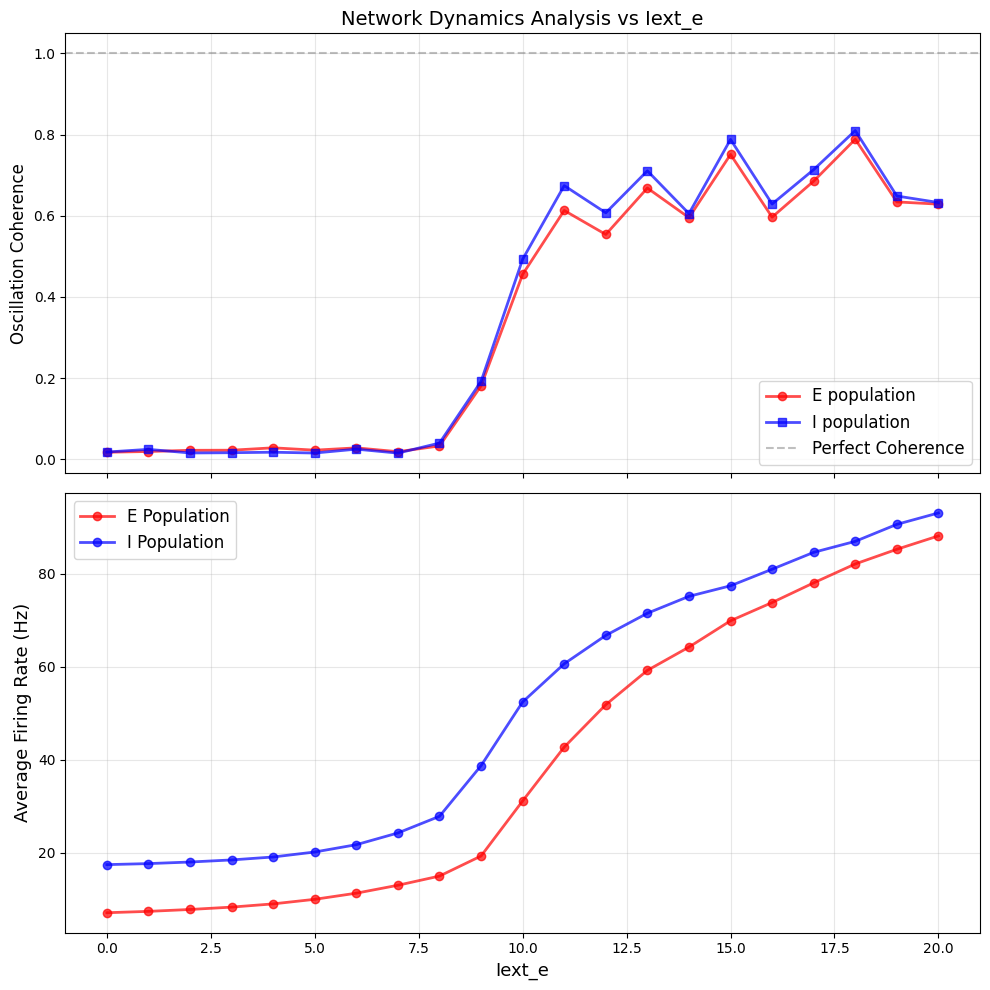

In [64]:
# Sweep Iext_e
Iext_e_range = np.linspace(0, 20, 21)

coherence_e, coherence_i, rates_e, rates_i = parameter_sweep('Iext_e', Iext_e_range)

plot_network_analysis(Iext_e_range, coherence_e, coherence_i, rates_e, rates_i, 'Iext_e')
plt.show()


We fix the external input to inhibitory population at $3$, and change the exitatory one from 0 to 20, to check its effects on network activiy:

Between $I^{ext}_e = 0$ and $8$, the coherence is near zero. This indicates an Asynchronous State where neurons fire randomly without coordination. Near $I^{ext}_e = 9$, we observe a sharp onset of synchrony, indicating a Hopf Bifurcation where the system transitions into a limit cycle (PING oscillation). And the coherence stabilizes between  0.6  and  0.8. This shows a robust, stable oscillation. The red (E) and blue (I) lines are almost perfectly identical. This confirms that the inhibitory neurons are tightly "locked" to the excitatory rhythm. The transition to limit cycle is accompanied by a significant increase in the firing rates of both populations, with the inhibitory neurons consistently maintaining a higher rate to enforce the rhythmic pacing of the network and creating a temporal and rhythmic excitability window that define the Gamma rhythm.




Running parameter sweep: Iext_i
Range: -5.0 to 20.0
------------------------------------------------------------


WARNING    'Iext_i' is an internal variable of group 'neurongroup_5', but also exists in the run namespace with the value np.float64(-5.0). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[1/21] Iext_i=-5.0 | E_Coh=0.59, I_Coh=0.65
E coherence=0.586, I coherence=0.648


WARNING    'Iext_i' is an internal variable of group 'neurongroup_7', but also exists in the run namespace with the value np.float64(-3.75). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


E coherence=0.541, I coherence=0.614


...

E coherence=0.021, I coherence=0.066


WARNING    'Iext_i' is an internal variable of group 'neurongroup_5', but also exists in the run namespace with the value np.float64(17.5). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


E coherence=0.027, I coherence=0.075


WARNING    'Iext_i' is an internal variable of group 'neurongroup_7', but also exists in the run namespace with the value np.float64(18.75). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


E coherence=0.021, I coherence=0.083
[21/21] Iext_i=20.0 | E_Coh=0.03, I_Coh=0.07
E coherence=0.025, I coherence=0.072
------------------------------------------------------------
Sweep Completed.


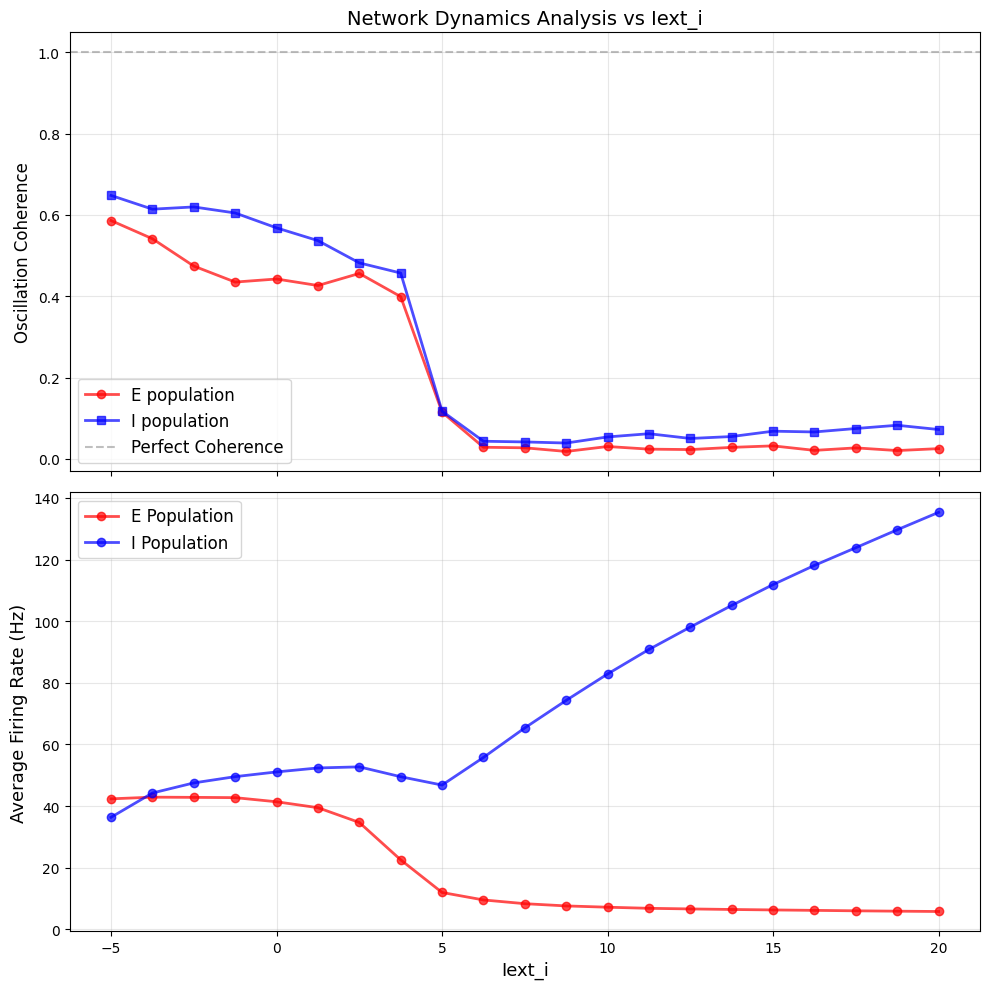

In [65]:
Iext_i_range = np.linspace(-5, 20, 21)
coherence_e_i, coherence_i_i, rates_e_i, rates_i_i= parameter_sweep('Iext_i', Iext_i_range)

plot_network_analysis(Iext_i_range, coherence_e_i, coherence_i_i, rates_e_i, rates_i_i, 'Iext_i')
plt.show()


We fix the external input to excitatory population at $10$, and change the inhibitory one from $-5$ to $20$, to check its effects on network activiy:

In contrast to the excitatory sweep, the network exhibits high coherence only when the inhibitory external drive is low ($-5 \le I^{ext}_i \le 4$). In this regime, the inhibitory population is primarily recruited by the excitatory neurons, allowing for a functional PING mechanism where E-cells lead and I-cells pace the rhythm. But, the stronger external drive to the inhibitory population ($I^{ext}_i > 5$) disrupts the PING mechanism where the stable limit cycle collapses. Because there is no coherence in the oscillation of the network. The excessive drive to the inhibitory population close the rhythmic excitability window. The average firing rate plot shows that by increasing input current to inhibitory population, the firing rate in excitatory population decreases but not completely silenced—continuing to fire at a low rate—their activity becomes desynchronized. The loss od E-cells coordination leads to a paradoxical effect on the I-population: Although the inhibitory firing rate increases, their spikes lose all coherence. This occurs because the inhibitory cells are no longer receiving the structured, periodic pulses from the E-cells that previously facilitated their synchronization.

---



## Step 5: Microscopic Phase Resetting Curve (mPRC)

We want to try to reproduce the phase response curve in the local network. In this regard, We utilize the run_ping_network function to generate a baseline reference signal. After discarding the initial transient activity, we calculate the mean oscillation period ($T$) by averaging the intervals between successive peaks of the population firing rate. We then implement the run_ping_pulse function to simulate the network's response to external perturbations. By injecting a brief excitatory pulse at various phases ($\phi$) within the oscillation cycle—targeting either the Excitatory (E) or Inhibitory (I) populations—we measure the resulting phase shift. This allows us to observe how the timing of a perturbation can either advance or delay the subsequent oscillation peaks.


In [39]:
from scipy.signal import find_peaks

I_e = 10
I_i = 0
duration_ctrl = 800*ms
transient = 300*ms

def run_ping_network(Iext_e, Iext_i, duration=200*ms, Ne=2000, Ni=2000):
    """Run PING network with given external inputs"""
    start_scope()

    # Time constants
    tau_e = 10 * ms
    tau_i = 10 * ms
    tau_s = 1 * ms
    tau_e_dim = tau_i_dim = 10

    # Lorentzian distribution parameters
    eta_mean_e = eta_mean_i = -5.0
    Delta_e = Delta_i = 1.0

    # Synaptic weights
    Jee = 0.0
    Jei = 15.0
    Jie = 15.0
    Jii = 0.0

    # Threshold and reset
    v_th = 50.0
    v_r = -50.0
    input_time = 10*ms

    # QIF equations
    eqs_e = '''
    dv/dt = (eta_e + v**2 + I_total) / tau_e : 1
    I_total = Iext_e * int(t>input_time) + tau_e_dim*(s_ee - s_ei) : 1
    ds_ee/dt = -s_ee / tau_s : 1
    ds_ei/dt = -s_ei / tau_s : 1
    eta_e : 1
    Iext_e : 1
    '''

    eqs_i = '''
    dv/dt = (eta_i + v**2 + I_total) / tau_i : 1
    I_total = Iext_i * int(t>input_time) + tau_i_dim*(s_ie - s_ii) : 1
    ds_ie/dt = -s_ie / tau_s : 1
    ds_ii/dt = -s_ii / tau_s : 1
    eta_i : 1
    Iext_i : 1
    '''

    # Create neuron groups
    E_neurons = NeuronGroup(Ne, eqs_e, threshold='v > v_th', reset='v = v_r', method='euler')
    I_neurons = NeuronGroup(Ni, eqs_i, threshold='v > v_th', reset='v = v_r', method='euler')

    # Initialize
    np.random.seed(42)
    E_neurons.eta_e = np.random.standard_cauchy(Ne) * Delta_e + eta_mean_e
    I_neurons.eta_i = np.random.standard_cauchy(Ni) * Delta_i + eta_mean_i
    E_neurons.v = np.random.uniform(-1, 1, Ne)
    I_neurons.v = np.random.uniform(-1, 1, Ni)
    E_neurons.Iext_e = Iext_e
    I_neurons.Iext_i = Iext_i

    # Synapses
    syn_ie = Synapses(I_neurons, E_neurons, on_pre='s_ei_post += Jei / Ni')
    syn_ie.connect()
    syn_ei = Synapses(E_neurons, I_neurons, on_pre='s_ie_post += Jie / Ne')
    syn_ei.connect()

    # Monitors
    rate_mon_e = PopulationRateMonitor(E_neurons)
    rate_mon_i = PopulationRateMonitor(I_neurons)

    # Run
    run(duration)



    return rate_mon_e, rate_mon_i


rm_e_ctrl, rm_i_ctrl = run_ping_network(I_e, I_i, duration=duration_ctrl)


WARNING    'Iext_e' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 10. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'Iext_i' is an internal variable of group 'neurongroup_3', but also exists in the run namespace with the value 0. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [40]:

dt = defaultclock.dt
start_idx = int(transient / dt)
rate_i = rm_i_ctrl.smooth_rate(window='flat', width=2*ms)/Hz
times = rm_i_ctrl.t/ms

peaks_ctrl, _ = find_peaks(rate_i[start_idx:], prominence=50)

peak_times_control = times[start_idx:][peaks_ctrl]

periods = np.diff(peak_times_control)
T_val = np.mean(periods)

print(f"Natural Period (T_val): {T_val:.2f} ms")
print(f"Number of control peaks: {len(peak_times_control)}")



Natural Period (T_val): 22.04 ms
Number of control peaks: 23


In [41]:
def run_ping_pulse(Iext_e, Iext_i, pulse_time, pulse_weight=10.0, target='E', duration=800*ms):
    start_scope()


    tau_e = 10 * ms
    tau_i = 10 * ms
    tau_s = 1 * ms
    tau_e_dim = tau_i_dim = 10


    eta_mean_e = -5.0
    eta_mean_i = -5.0


    Delta_e = 1.0
    Delta_i = 1.0
    v_th = 50.0
    v_r = -50.0

    eqs_e = '''
    dv/dt = (eta_e + v**2 + I_total + I_pulse) / tau_e : 1
    I_total = Iext_e * int(t>10*ms) + tau_e_dim*(s_ee - s_ei) : 1
    I_pulse = pulse_val : 1
    ds_ee/dt = -s_ee / tau_s : 1
    ds_ei/dt = -s_ei / tau_s : 1
    pulse_val : 1
    eta_e : 1
    '''

    eqs_i = '''
    dv/dt = (eta_i + v**2 + I_total + I_pulse) / tau_i : 1
    I_total = Iext_i * int(t>10*ms) + tau_i_dim*(s_ie - s_ii) : 1
    I_pulse = pulse_val : 1
    ds_ie/dt = -s_ie / tau_s : 1
    ds_ii/dt = -s_ii / tau_s : 1
    pulse_val : 1
    eta_i : 1
    '''

    E_neurons = NeuronGroup(2000, eqs_e, threshold='v > v_th', reset='v = v_r', method='euler')
    I_neurons = NeuronGroup(2000, eqs_i, threshold='v > v_th', reset='v = v_r', method='euler')


    np.random.seed(42)
    E_neurons.eta_e = np.random.standard_cauchy(2000) * Delta_e + eta_mean_e
    I_neurons.eta_i = np.random.standard_cauchy(2000) * Delta_i + eta_mean_i
    E_neurons.v = np.random.uniform(-1, 1, 2000)
    I_neurons.v = np.random.uniform(-1, 1, 2000)

    syn_ie = Synapses(I_neurons, E_neurons, on_pre='s_ei_post += 15.0 / 2000')
    syn_ie.connect()
    syn_ei = Synapses(E_neurons, I_neurons, on_pre='s_ie_post += 15.0 / 2000')
    syn_ei.connect()


    rate_mon_i = PopulationRateMonitor(I_neurons)
    rate_mon_e = PopulationRateMonitor(E_neurons)

    @network_operation(dt=defaultclock.dt)
    def apply_pulse(t):
        if abs(t - pulse_time) < defaultclock.dt/2:
            if target == 'E':
                E_neurons.pulse_val = pulse_weight / (defaultclock.dt/ms)
            else:
                I_neurons.pulse_val = pulse_weight / (defaultclock.dt/ms)
        else:
            E_neurons.pulse_val = 0
            I_neurons.pulse_val = 0
    run(duration)
    return rate_mon_i




In [42]:
phases = np.linspace(0, 1, 50)
mprc_results_e = []

base_peak_time = peak_times_control[len(peak_times_control)//2]

for phi in phases:
    t_p = (base_peak_time + phi * T_val) * ms

    rm_p = run_ping_pulse(Iext_e=10, Iext_i=0, pulse_time=t_p, pulse_weight=5.0, target='E')

    rate_p = rm_p.smooth_rate(window='flat', width=2*ms)/Hz
    peaks_p, _ = find_peaks(rate_p[start_idx:], prominence=50)
    peak_times_p = (rm_p.t[start_idx:][peaks_p]) / ms

    n = min(len(peak_times_p), len(peak_times_control))
    final_shift = peak_times_control[n-1] - peak_times_p[n-1]

    mprc_results_e.append(final_shift / T_val)
    print(f"Phase: {phi:.2f} | Cumulative Shift: {mprc_results_e[-1]:.2f}")




Phase: 0.00 | Cumulative Shift: -0.00
Phase: 0.02 | Cumulative Shift: -0.00
Phase: 0.04 | Cumulative Shift: -0.00
Phase: 0.06 | Cumulative Shift: -0.01
Phase: 0.08 | Cumulative Shift: 0.00
Phase: 0.10 | Cumulative Shift: 0.00
Phase: 0.12 | Cumulative Shift: 0.00
Phase: 0.14 | Cumulative Shift: 0.01
Phase: 0.16 | Cumulative Shift: 0.01
Phase: 0.18 | Cumulative Shift: 0.01
Phase: 0.20 | Cumulative Shift: 0.02
Phase: 0.22 | Cumulative Shift: 0.03
Phase: 0.24 | Cumulative Shift: 0.03
Phase: 0.27 | Cumulative Shift: 0.04
Phase: 0.29 | Cumulative Shift: 0.04
Phase: 0.31 | Cumulative Shift: 0.05
Phase: 0.33 | Cumulative Shift: 0.06
Phase: 0.35 | Cumulative Shift: 0.08
Phase: 0.37 | Cumulative Shift: 0.08
Phase: 0.39 | Cumulative Shift: 0.09
Phase: 0.41 | Cumulative Shift: 0.09
Phase: 0.43 | Cumulative Shift: 0.09
Phase: 0.45 | Cumulative Shift: 0.08
Phase: 0.47 | Cumulative Shift: 0.08
Phase: 0.49 | Cumulative Shift: 0.09
Phase: 0.51 | Cumulative Shift: 0.09
Phase: 0.53 | Cumulative Shift: 0.

WARNING    <>:7: SyntaxWarning: invalid escape sequence '\D'
 [py.warnings]

WARNING    <>:7: SyntaxWarning: invalid escape sequence '\D'
 [py.warnings]

WARNING    /tmp/ipython-input-2720393952.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E-mPRC ($\Delta \Phi$)', fontsize=13)
 [py.warnings]
  plt.ylabel('E-mPRC ($\Delta \Phi$)', fontsize=13)



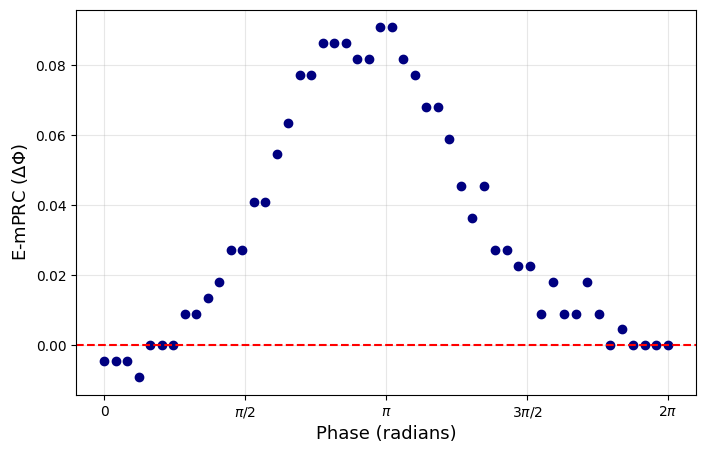

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(phases * 2 * np.pi, mprc_results_e, 'o', color='navy', linewidth=2)
plt.axhline(0, color='red', linestyle='--')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.xlabel('Phase (radians)', fontsize=13)
plt.ylabel('E-mPRC ($\Delta \Phi$)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()

When an excitatory pulse is injected into the E-cells, the network rhythm typically exhibits a monophasic response. Since the pulse provides additional excitation directly to the excitatory population. This leads exclusively to a phase advance, meaning the next cycle always occurs earlier regardless of the injection phase.

In [44]:
phases = np.linspace(0, 1, 50)
mprc_results_i= []

base_peak_time = peak_times_control[len(peak_times_control)//2]

for phi in phases:
    t_p = (base_peak_time + phi * T_val) * ms

    rm_p = run_ping_pulse(Iext_e=10, Iext_i=0, pulse_time=t_p, pulse_weight=5.0, target='I')

    rate_p = rm_p.smooth_rate(window='flat', width=2*ms)/Hz
    peaks_p, _ = find_peaks(rate_p[start_idx:], prominence=50)
    peak_times_p = (rm_p.t[start_idx:][peaks_p]) / ms

    n = min(len(peak_times_p), len(peak_times_control))
    final_shift = peak_times_control[n-1] - peak_times_p[n-1]

    mprc_results_i.append(final_shift / T_val)
    print(f"Phase: {phi:.2f} | Cumulative Shift: {mprc_results_i[-1]:.2f}")


Phase: 0.00 | Cumulative Shift: 0.00
Phase: 0.02 | Cumulative Shift: 0.00
Phase: 0.04 | Cumulative Shift: 0.00
Phase: 0.06 | Cumulative Shift: 0.01
Phase: 0.08 | Cumulative Shift: -0.00
Phase: 0.10 | Cumulative Shift: 0.00
Phase: 0.12 | Cumulative Shift: -0.01
Phase: 0.14 | Cumulative Shift: -0.01
Phase: 0.16 | Cumulative Shift: -0.01
Phase: 0.18 | Cumulative Shift: -0.01
Phase: 0.20 | Cumulative Shift: -0.01
Phase: 0.22 | Cumulative Shift: -0.01
Phase: 0.24 | Cumulative Shift: -0.01
Phase: 0.27 | Cumulative Shift: -0.01
Phase: 0.29 | Cumulative Shift: -0.01
Phase: 0.31 | Cumulative Shift: -0.01
Phase: 0.33 | Cumulative Shift: -0.01
Phase: 0.35 | Cumulative Shift: -0.01
Phase: 0.37 | Cumulative Shift: -0.02
Phase: 0.39 | Cumulative Shift: -0.01
Phase: 0.41 | Cumulative Shift: -0.02
Phase: 0.43 | Cumulative Shift: -0.00
Phase: 0.45 | Cumulative Shift: -0.00
Phase: 0.47 | Cumulative Shift: -0.01
Phase: 0.49 | Cumulative Shift: -0.01
Phase: 0.51 | Cumulative Shift: -0.01
Phase: 0.53 | Cum

WARNING    <>:7: SyntaxWarning: invalid escape sequence '\D'
 [py.warnings]

WARNING    <>:7: SyntaxWarning: invalid escape sequence '\D'
 [py.warnings]

WARNING    /tmp/ipython-input-3244623911.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('I-mPRC ($\Delta \Phi$)', fontsize=13)
 [py.warnings]
  plt.ylabel('I-mPRC ($\Delta \Phi$)', fontsize=13)



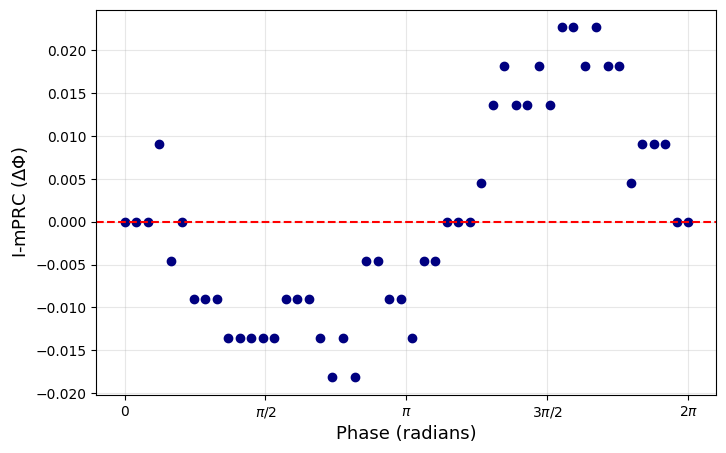

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(phases * 2 * np.pi, mprc_results_i, 'o', color='navy', linewidth=2)
plt.axhline(0, color='red', linestyle='--')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.xlabel('Phase (radians)', fontsize=13)
plt.ylabel('I-mPRC ($\Delta \Phi$)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()

In our code, the period is calculated based on the successive peaks of the inhibitory population's firing rate. When an excitatory pulse is injected into the I-cells, we observe a biphasic response:

First Half (Phase Delay): If the pulse occurs during the first half of the cycle—when I-cells are already firing or have just finished—it provides extra excitation to the inhibitory population. This strengthens or prolongs the inhibition felt by the E-cells. As a result, the E-cells take longer to recover and reach their threshold, which delays the next cycle.

Second Half (Phase Advance): If the pulse is injected during the second half of the cycle—approaching the time when E-cells would normally trigger the next round of I-cells—it causes the I-cells to fire sooner than expected. By 'forcing' the inhibitory peak to occur earlier, the current cycle is completed faster, allowing the next cycle to start sooner (advance).

It is important to note that the amplitudes of PRCs show us the network is more sensetive tp perturbations onto excitatorty cells than inhibitory cells.